# Many Coin Flips

Based on [Probability for Computer Scientists — Many Coin Flips](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/many_flips/)

We flip a coin $n$ times. Each flip lands heads with probability $p$.  
This chapter derives the formula for the **number of heads** — the foundation of the **Binomial distribution**.

> **Notation:** `H` = Heads, `T` = Tails. Each coin flip is **independent**.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from math import comb, factorial
from itertools import combinations
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print('Setup complete!')

Setup complete!


---
## 1 · Coin Flip Simulator

Use the controls below to set $n$ (number of flips) and $p$ (probability of heads), then click **Flip!**

In [2]:
# --- Interactive coin flip simulator ---
n_slider = widgets.IntSlider(value=10, min=1, max=50, step=1,
                             description='n (flips):', style={'description_width': 'initial'})
p_slider = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05,
                               description='p (heads):', readout_format='.2f',
                               style={'description_width': 'initial'})
flip_btn = widgets.Button(description='Flip!', button_style='primary')
output = widgets.Output()

def flip_coins(btn):
    with output:
        clear_output(wait=True)
        n, p = n_slider.value, p_slider.value
        flips = np.random.random(n) < p
        symbols = ['H' if h else 'T' for h in flips]
        n_heads = sum(flips)

        # Coloured display
        colored = [f'\033[92mH\033[0m' if h else f'\033[91mT\033[0m' for h in flips]
        print('Result: ' + ', '.join(colored))
        print(f'Total heads: {n_heads} / {n}')

        # Mini bar chart of this flip
        fig, ax = plt.subplots(figsize=(max(n * 0.35, 4), 1.5))
        colors = ['#2E7D32' if h else '#C62828' for h in flips]
        ax.bar(range(n), [1]*n, color=colors, edgecolor='white', linewidth=0.5)
        ax.set_xticks(range(n))
        ax.set_xticklabels(symbols, fontsize=8)
        ax.set_yticks([])
        ax.set_title(f'{n_heads} heads out of {n} flips  (p={p})', fontsize=10)
        plt.tight_layout()
        plt.show()

flip_btn.on_click(flip_coins)
display(widgets.HBox([n_slider, p_slider, flip_btn]))
display(output)
flip_coins(None)  # initial flip

Output()

---
## 2 · Warmups

We'll work through three building-block questions. In each case, $n = 10$ and $p = 0.6$.

### 2a · All $n$ flips are heads

The outcome is: `H, H, H, H, H, H, H, H, H, H`

Since each flip is independent:

$$P(\text{all heads}) = \underbrace{p \cdot p \cdots p}_{n \text{ times}} = p^n$$

P(all 10 heads) = 0.6^10 = 0.006047


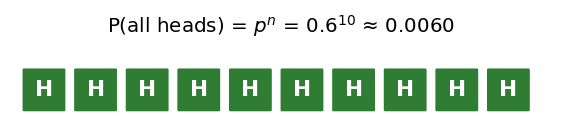

In [3]:
n, p = 10, 0.6

prob_all_heads = p ** n
print(f'P(all {n} heads) = {p}^{n} = {prob_all_heads:.6f}')

# Visual: sequence of green squares
fig, ax = plt.subplots(figsize=(8, 1.2))
for i in range(n):
    ax.add_patch(FancyBboxPatch((i, 0), 0.8, 0.8, boxstyle='round,pad=0.05',
                                facecolor='#2E7D32', edgecolor='white', linewidth=2))
    ax.text(i + 0.4, 0.4, 'H', ha='center', va='center', fontsize=12,
            color='white', weight='bold')
ax.set_xlim(-0.2, n + 0.2)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'P(all heads) = $p^n$ = $0.6^{{10}}$ ≈ {prob_all_heads:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

### 2b · All $n$ flips are tails

The outcome is: `T, T, T, T, T, T, T, T, T, T`

$$P(\text{all tails}) = (1-p)^n$$

P(all 10 tails) = (1-0.6)^10 = 0.4^10 = 0.000105


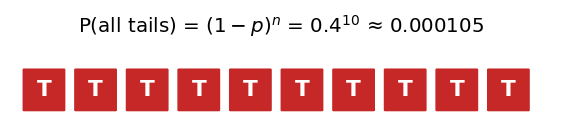

In [4]:
prob_all_tails = (1 - p) ** n
print(f'P(all {n} tails) = (1-{p})^{n} = {1-p}^{n} = {prob_all_tails:.6f}')

fig, ax = plt.subplots(figsize=(8, 1.2))
for i in range(n):
    ax.add_patch(FancyBboxPatch((i, 0), 0.8, 0.8, boxstyle='round,pad=0.05',
                                facecolor='#C62828', edgecolor='white', linewidth=2))
    ax.text(i + 0.4, 0.4, 'T', ha='center', va='center', fontsize=12,
            color='white', weight='bold')
ax.set_xlim(-0.2, n + 0.2)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'P(all tails) = $(1-p)^n$ = $0.4^{{10}}$ ≈ {prob_all_tails:.6f}', fontsize=11)
plt.tight_layout()
plt.show()

### 2c · First $k$ heads, then $n-k$ tails

For $k = 4$, the outcome is: `H, H, H, H, T, T, T, T, T, T`

$$P(\text{first } k \text{ heads, then } n-k \text{ tails}) = p^k \cdot (1-p)^{n-k}$$

P(first 4 heads then 6 tails) = 0.6^4 · 0.4^6 = 0.000531


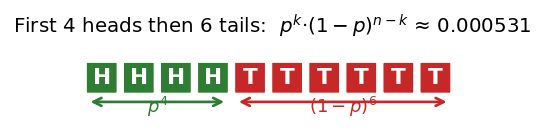

In [5]:
k = 4
prob_k_then_rest = p**k * (1 - p)**(n - k)
print(f'P(first {k} heads then {n-k} tails) = {p}^{k} · {1-p}^{n-k} = {prob_k_then_rest:.6f}')

fig, ax = plt.subplots(figsize=(8, 1.2))
for i in range(n):
    is_head = i < k
    color = '#2E7D32' if is_head else '#C62828'
    label = 'H' if is_head else 'T'
    ax.add_patch(FancyBboxPatch((i, 0), 0.8, 0.8, boxstyle='round,pad=0.05',
                                facecolor=color, edgecolor='white', linewidth=2))
    ax.text(i + 0.4, 0.4, label, ha='center', va='center', fontsize=12,
            color='white', weight='bold')

# Bracket annotations
ax.annotate('', xy=(0, -0.25), xytext=(k - 0.2, -0.25),
            arrowprops=dict(arrowstyle='<->', color='#2E7D32', lw=1.5))
ax.text(k/2 - 0.1, -0.55, f'$p^{k}$', ha='center', fontsize=10, color='#2E7D32')

ax.annotate('', xy=(k, -0.25), xytext=(n - 0.2, -0.25),
            arrowprops=dict(arrowstyle='<->', color='#C62828', lw=1.5))
ax.text((k + n)/2 - 0.1, -0.55, f'$(1-p)^{{{n-k}}}$', ha='center', fontsize=10, color='#C62828')

ax.set_xlim(-0.2, n + 0.2)
ax.set_ylim(-0.9, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'First {k} heads then {n-k} tails:  $p^k · (1-p)^{{n-k}}$ ≈ {prob_k_then_rest:.6f}',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## 3 · Exactly $k$ heads (The Key Derivation)

Now the big question: what is the probability of getting **exactly** $k$ heads in $n$ flips, in **any order**?

### Step 1: Count the orderings

How many ways can we arrange $k$ heads among $n$ positions?

$$N = \binom{n}{k} = \frac{n!}{k!(n-k)!}$$

### Step 2: Probability of each ordering

**Every** ordering with exactly $k$ heads has the **same** probability (since multiplication is commutative):

$$P(E_i) = p^k \cdot (1-p)^{n-k}$$

### Step 3: Combine (events are mutually exclusive)

$$\boxed{P(\text{exactly } k \text{ heads}) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}}$$

In [6]:
# --- Show all orderings for k=4 heads in n=10 flips ---
n, k, p = 10, 4, 0.6

# Generate all orderings: choose which k positions are heads
orderings = list(combinations(range(n), k))
N = len(orderings)
print(f'Number of orderings: C({n},{k}) = {comb(n,k)} = {N}')
print(f'Each ordering has probability: p^k · (1-p)^(n-k) = {p**k * (1-p)**(n-k):.6f}')
print(f'P(exactly {k} heads) = C({n},{k}) · p^{k} · (1-p)^{n-k} = {comb(n,k) * p**k * (1-p)**(n-k):.6f}')
print(f'\nFirst 8 orderings (of {N}):')
for idx, heads_pos in enumerate(orderings[:8]):
    seq = ['H' if i in heads_pos else 'T' for i in range(n)]
    print(f'  E_{idx+1:>3}: ({", ".join(seq)})')
print(f'  ...  ({N - 8} more)')

Number of orderings: C(10,4) = 210 = 210
Each ordering has probability: p^k · (1-p)^(n-k) = 0.000531
P(exactly 4 heads) = C(10,4) · p^4 · (1-p)^6 = 0.111477

First 8 orderings (of 210):
  E_  1: (H, H, H, H, T, T, T, T, T, T)
  E_  2: (H, H, H, T, H, T, T, T, T, T)
  E_  3: (H, H, H, T, T, H, T, T, T, T)
  E_  4: (H, H, H, T, T, T, H, T, T, T)
  E_  5: (H, H, H, T, T, T, T, H, T, T)
  E_  6: (H, H, H, T, T, T, T, T, H, T)
  E_  7: (H, H, H, T, T, T, T, T, T, H)
  E_  8: (H, H, T, H, H, T, T, T, T, T)
  ...  (202 more)


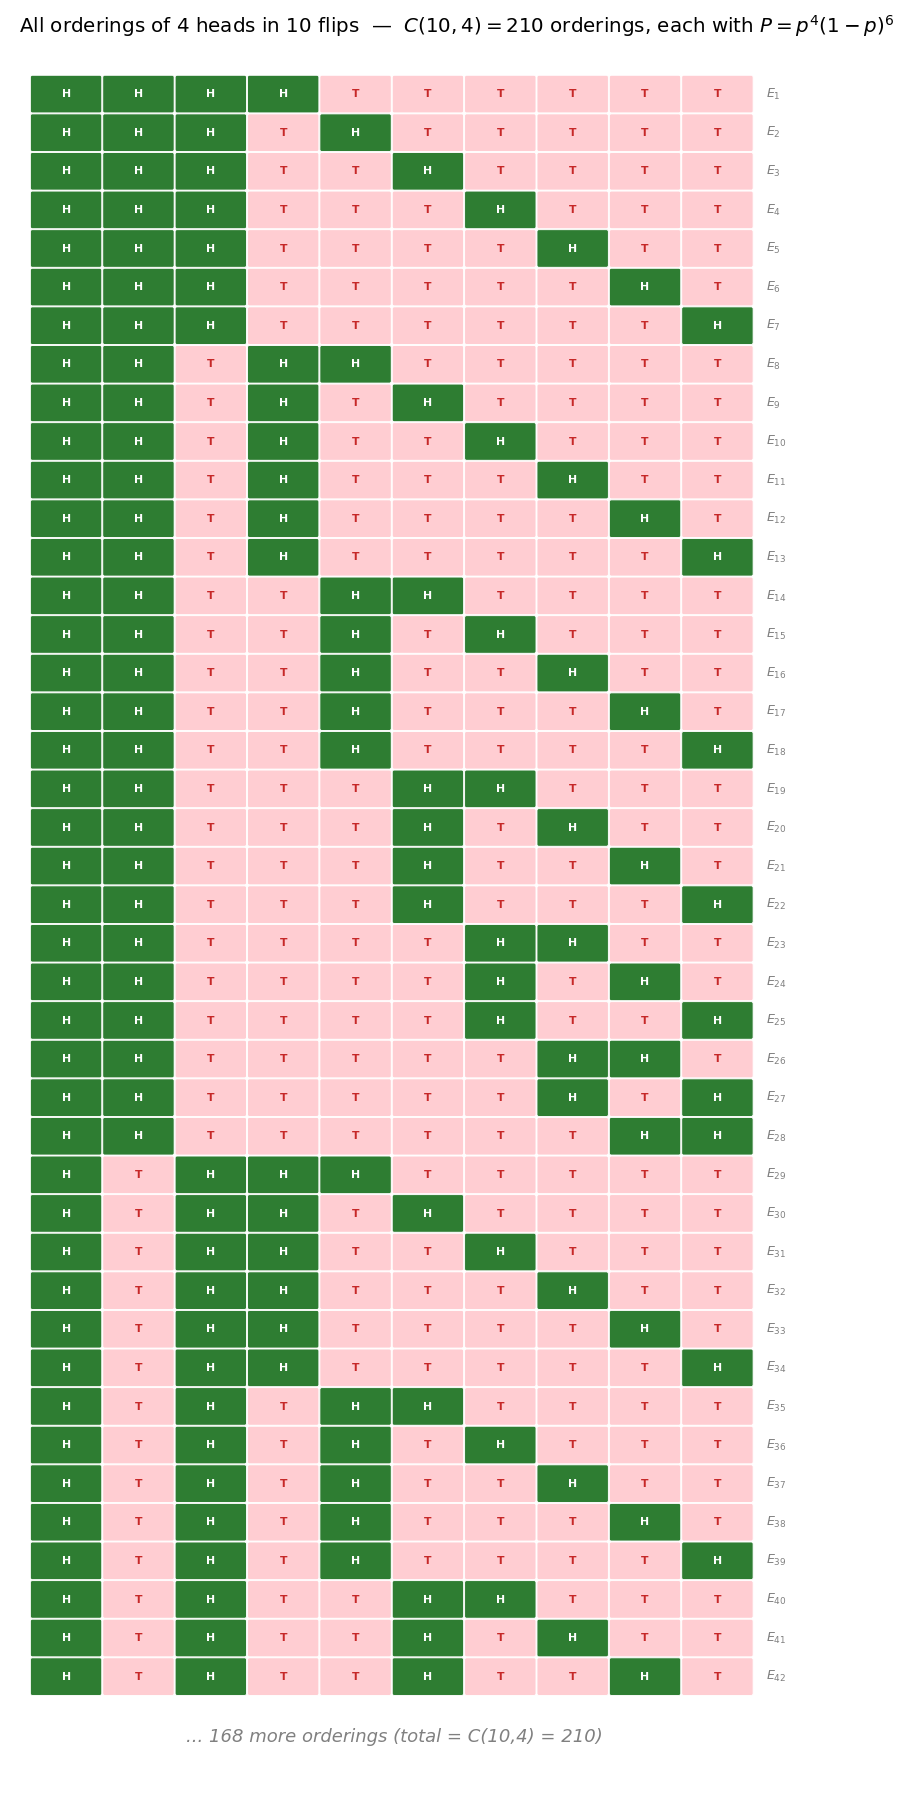

In [7]:
# --- Visualize: grid of all 210 orderings ---
fig, ax = plt.subplots(figsize=(10, 14))

rows_to_show = min(N, 42)  # show first 42 rows
cell_w, cell_h = 0.7, 0.35
gap = 0.05

for row_idx in range(rows_to_show):
    heads_pos = orderings[row_idx]
    y = (rows_to_show - 1 - row_idx) * (cell_h + gap)
    for col in range(n):
        is_head = col in heads_pos
        color = '#2E7D32' if is_head else '#FFCDD2'
        x = col * (cell_w + gap)
        ax.add_patch(FancyBboxPatch((x, y), cell_w, cell_h,
                     boxstyle='round,pad=0.02', facecolor=color,
                     edgecolor='white', linewidth=0.5))
        ax.text(x + cell_w/2, y + cell_h/2,
                'H' if is_head else 'T',
                ha='center', va='center', fontsize=6,
                color='white' if is_head else '#C62828', weight='bold')
    # Row label
    ax.text(n * (cell_w + gap) + 0.1, y + cell_h/2,
            f'$E_{{{row_idx+1}}}$', va='center', fontsize=7, color='grey')

if N > rows_to_show:
    ax.text(n * (cell_w + gap) / 2, -0.5,
            f'... {N - rows_to_show} more orderings (total = C({n},{k}) = {N})',
            ha='center', fontsize=10, color='grey', style='italic')

ax.set_xlim(-0.2, n * (cell_w + gap) + 1.5)
ax.set_ylim(-1, rows_to_show * (cell_h + gap) + 0.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'All orderings of {k} heads in {n} flips  —  '
             f'$C({n},{k}) = {N}$ orderings, each with '
             f'$P = p^{k}(1-p)^{{{n-k}}}$', fontsize=11)
plt.tight_layout()
plt.show()

### Key insight: why every ordering has the same probability

Take **any** ordering with $k$ heads. Since the flips are independent, the probability is a product of $k$ copies of $p$ and $(n-k)$ copies of $(1-p)$. Multiplication is commutative, so the **order doesn't matter**:

$$P(E_i) = \underbrace{p \cdot p \cdots p}_{k} \cdot \underbrace{(1-p) \cdot (1-p) \cdots (1-p)}_{n-k} = p^k(1-p)^{n-k}$$

In [8]:
# --- Demonstrate: pick any ordering, probability is the same ---
rng = np.random.default_rng(42)
samples = rng.choice(len(orderings), size=5, replace=False)
expected = p**k * (1-p)**(n-k)

print(f'Expected probability for each ordering: p^k · (1-p)^(n-k) = {expected:.6f}\n')
for idx in samples:
    heads_pos = orderings[idx]
    seq = ['H' if i in heads_pos else 'T' for i in range(n)]
    # Compute the probability flip by flip
    prob = 1.0
    terms = []
    for i in range(n):
        if i in heads_pos:
            prob *= p
            terms.append(f'{p}')
        else:
            prob *= (1 - p)
            terms.append(f'{1-p}')
    print(f'  E_{idx+1:>3}: ({", ".join(seq)})')
    print(f'         P = {" × ".join(terms)} = {prob:.6f}  ✓')

Expected probability for each ordering: p^k · (1-p)^(n-k) = 0.000531

  E_161: (T, T, H, T, H, T, H, T, H, T)
         P = 0.4 × 0.4 × 0.6 × 0.4 × 0.6 × 0.4 × 0.6 × 0.4 × 0.6 × 0.4 = 0.000531  ✓
  E_ 92: (T, H, H, T, H, T, H, T, T, T)
         P = 0.4 × 0.6 × 0.6 × 0.4 × 0.6 × 0.4 × 0.6 × 0.4 × 0.4 × 0.4 = 0.000531  ✓
  E_137: (T, H, T, T, T, T, H, H, H, T)
         P = 0.4 × 0.6 × 0.4 × 0.4 × 0.4 × 0.4 × 0.6 × 0.6 × 0.6 × 0.4 = 0.000531  ✓
  E_ 19: (H, H, T, T, T, H, H, T, T, T)
         P = 0.6 × 0.6 × 0.4 × 0.4 × 0.4 × 0.6 × 0.6 × 0.4 × 0.4 × 0.4 = 0.000531  ✓
  E_ 91: (T, H, H, T, H, H, T, T, T, T)
         P = 0.4 × 0.6 × 0.6 × 0.4 × 0.6 × 0.6 × 0.4 × 0.4 × 0.4 × 0.4 = 0.000531  ✓


---
## 4 · Interactive: Probability distribution over $k$

Use the sliders to explore how the distribution of heads changes with $n$ and $p$.

In [9]:
# --- Interactive probability distribution ---
def plot_distribution(n, p):
    k_vals = np.arange(0, n + 1)
    probs = [comb(n, k) * p**k * (1-p)**(n-k) for k in k_vals]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors = ['#1565C0' if pr < max(probs) else '#C62828' for pr in probs]
    ax.bar(k_vals, probs, color=colors, edgecolor='white', linewidth=0.8, alpha=0.85)

    # Highlight the mode
    mode_k = k_vals[np.argmax(probs)]
    ax.text(mode_k, max(probs) + 0.005,
            f'mode = {mode_k}\nP ≈ {max(probs):.4f}',
            ha='center', fontsize=9, color='#C62828', weight='bold')

    # Expected value line
    expected = n * p
    ax.axvline(expected, color='#2E7D32', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(expected + 0.3, max(probs) * 0.8, f'E[k] = np = {expected:.1f}',
            fontsize=9, color='#2E7D32')

    ax.set_xlabel('Number of heads $k$')
    ax.set_ylabel('$P(\\text{exactly } k \\text{ heads})$')
    ax.set_title(f'$P(k) = C({n}, k) \\cdot {p}^k \\cdot {1-p:.2f}^{{{n}-k}}$',
                 fontsize=12)
    if n <= 30:
        ax.set_xticks(k_vals)
    plt.tight_layout()
    plt.show()
    print(f'Sum of all probabilities: {sum(probs):.10f}  (should be 1.0)')

n_w = widgets.IntSlider(value=10, min=1, max=60, step=1,
                        description='n (flips):',
                        style={'description_width': 'initial'})
p_w = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05,
                          description='p (heads):', readout_format='.2f',
                          style={'description_width': 'initial'})

widgets.interact(plot_distribution, n=n_w, p=p_w);

interactive(children=(IntSlider(value=10, description='n (flips):', max=60, min=1, style=SliderStyle(descripti…

---
## 5 · More than $k$ heads

What if we want $P(\text{more than } k \text{ heads})$?

The events "exactly $i$ heads" for different values of $i$ are **mutually exclusive** (you can't simultaneously have exactly 4 and exactly 5 heads). So:

$$P(\text{more than } k \text{ heads}) = \sum_{i=k+1}^{n} \binom{n}{i} \cdot p^i \cdot (1-p)^{n-i}$$

In [10]:
# --- Visualize: more than k heads (shaded tail) ---
def plot_more_than_k(n, p, k):
    k_vals = np.arange(0, n + 1)
    probs = np.array([comb(n, i) * p**i * (1-p)**(n-i) for i in k_vals])

    fig, ax = plt.subplots(figsize=(10, 4.5))

    # bars for k <= threshold (grey)
    colors = ['#B0BEC5' if i <= k else '#C62828' for i in k_vals]
    ax.bar(k_vals, probs, color=colors, edgecolor='white', linewidth=0.8, alpha=0.85)

    prob_more = sum(probs[k+1:])
    prob_at_most = sum(probs[:k+1])

    ax.set_xlabel('Number of heads $i$')
    ax.set_ylabel('$P(\\text{exactly } i \\text{ heads})$')
    ax.set_title(f'$P(\\text{{more than }} {k} \\text{{ heads}}) = '
                 f'\\sum_{{i={k+1}}}^{{{n}}} C({n},i) \\cdot p^i \\cdot (1-p)^{{{n}-i}}'
                 f' \\approx {prob_more:.4f}$',
                 fontsize=11)
    if n <= 30:
        ax.set_xticks(k_vals)

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#B0BEC5', label=f'≤ {k} heads  (P ≈ {prob_at_most:.4f})'),
        Patch(facecolor='#C62828', label=f'> {k} heads  (P ≈ {prob_more:.4f})'),
    ], fontsize=9)

    plt.tight_layout()
    plt.show()

n_w2 = widgets.IntSlider(value=10, min=1, max=60, step=1,
                         description='n (flips):',
                         style={'description_width': 'initial'})
p_w2 = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05,
                           description='p (heads):', readout_format='.2f',
                           style={'description_width': 'initial'})
k_w2 = widgets.IntSlider(value=4, min=0, max=59, step=1,
                         description='k (threshold):',
                         style={'description_width': 'initial'})

def update_k_max(*args):
    k_w2.max = n_w2.value - 1
n_w2.observe(update_k_max, 'value')

widgets.interact(plot_more_than_k, n=n_w2, p=p_w2, k=k_w2);

interactive(children=(IntSlider(value=10, description='n (flips):', max=60, min=1, style=SliderStyle(descripti…

---
## 6 · Numerical examples

Let's compute a table of exact probabilities for $n = 10$, $p = 0.6$.

In [11]:
n, p = 10, 0.6
print(f'n = {n},  p = {p}')
print(f'{"k":>3}  {"C(n,k)":>8}  {"p^k":>12}  {"(1-p)^(n-k)":>14}  {"P(exactly k)":>14}  {"P(more than k)":>16}')
print('-' * 78)

for k in range(n + 1):
    c = comb(n, k)
    pk = p**k
    qnk = (1-p)**(n-k)
    exact = c * pk * qnk
    more = sum(comb(n, i) * p**i * (1-p)**(n-i) for i in range(k+1, n+1))
    print(f'{k:>3}  {c:>8}  {pk:>12.6f}  {qnk:>14.6f}  {exact:>14.6f}  {more:>16.6f}')

n = 10,  p = 0.6
  k    C(n,k)           p^k     (1-p)^(n-k)    P(exactly k)    P(more than k)
------------------------------------------------------------------------------
  0         1      1.000000        0.000105        0.000105          0.999895
  1        10      0.600000        0.000262        0.001573          0.998322
  2        45      0.360000        0.000655        0.010617          0.987705
  3       120      0.216000        0.001638        0.042467          0.945238
  4       210      0.129600        0.004096        0.111477          0.833761
  5       252      0.077760        0.010240        0.200658          0.633103
  6       210      0.046656        0.025600        0.250823          0.382281
  7       120      0.027994        0.064000        0.214991          0.167290
  8        45      0.016796        0.160000        0.120932          0.046357
  9        10      0.010078        0.400000        0.040311          0.006047
 10         1      0.006047        1.000000   

---
## 7 · Summary

| Question | Formula |
|----------|----------|
| All $n$ heads | $p^n$ |
| All $n$ tails | $(1-p)^n$ |
| First $k$ heads then $n-k$ tails | $p^k \cdot (1-p)^{n-k}$ |
| **Exactly $k$ heads** (any order) | $\displaystyle\binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$ |
| More than $k$ heads | $\displaystyle\sum_{i=k+1}^{n} \binom{n}{i} \cdot p^i \cdot (1-p)^{n-i}$ |

The "exactly $k$ heads" formula is the basis of the **Binomial distribution** — one of the most important distributions in probability and statistics.